In [46]:
from pathlib import Path

GTFS_PATH = Path("data/raw/GTFS_Copenhagen.zip")

if not GTFS_PATH.exists():
    raise FileNotFoundError(
        "GTFS ZIP not found. Download it as described in README.md"
    )


In [49]:
import zipfile
import pandas as pd

with zipfile.ZipFile(GTFS_PATH, "r") as z:
    names = z.namelist()
    print("Number of files in zip:", len(names))
   # for n in names[:24]:
            # print(" -", n)


Number of files in zip: 24


In [50]:
with zipfile.ZipFile(GTFS_PATH, "r") as z:
    stops = pd.read_csv(z.open("GTFS_Copenhagen/stops.txt"))
    routes = pd.read_csv(z.open("GTFS_Copenhagen/routes.txt"))
    shapes = pd.read_csv(z.open("GTFS_Copenhagen/shapes.txt"))
    stop_times = pd.read_csv(z.open("GTFS_Copenhagen/stop_times.txt"))
    trips = pd.read_csv(z.open("GTFS_Copenhagen/trips.txt"))

/var/folders/qh/2gv9htfj0554_hzssc218vg40000gn/T/ipykernel_79983/753648010.py:5: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  stop_times = pd.read_csv(z.open("GTFS_Copenhagen/stop_times.txt"))


In [51]:
stops.head()

,stop_id,stop_code,stop_name,stop_desc,stop_lat,stop_lon,location_type,parent_station,wheelchair_boarding,platform_code
0,461011300,NaN,Dyrupgårds Alle (Odense Kommune),NaN,55.354917,10.345034,0,NaN,0,NaN
1,8600718,NaN,Vipperød St.,NaN,55.666828,11.738710,0,NaN,0,NaN
2,8600719,NaN,Holbæk St.,NaN,55.715750,11.708598,0,NaN,0,NaN
3,8600716,NaN,Hvalsø St.,NaN,55.595537,11.859821,0,NaN,0,NaN
4,8600717,NaN,Tølløse St.,NaN,55.611893,11.772803,0,NaN,0,NaN


In [65]:
# stops filtering for metro only
metro_stops = stops[stops['stop_name'].str.contains('(Metro)')]

# remove the line based on stop_id
metro_stops = metro_stops[metro_stops["stop_id"] != 821004401]

print(len(metro_stops))

44


/var/folders/qh/2gv9htfj0554_hzssc218vg40000gn/T/ipykernel_79983/2102663247.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  metro_stops = stops[stops['stop_name'].str.contains('(Metro)')]


In [19]:
metro_stops.head()

,stop_id,stop_code,stop_name,stop_desc,stop_lat,stop_lon,location_type,parent_station,wheelchair_boarding,platform_code
51,8603317,NaN,Vestamager St. (Metro),NaN,55.619391,12.575297,0,NaN,0,NaN
52,8603315,NaN,Ørestad St. (Metro),NaN,55.629055,12.579389,0,NaN,0,NaN
53,8603312,NaN,Sundby St. (Metro),NaN,55.645199,12.585728,0,NaN,0,NaN
54,8603313,NaN,Bella Center St. (Metro),NaN,55.638051,12.582928,0,NaN,0,NaN
55,8603310,NaN,Islands Brygge St. (Metro),NaN,55.663422,12.585217,0,NaN,0,NaN


In [67]:
# clean up stop_times to only metro stops
metro_stop_times = stop_times[stop_times["stop_id"].isin(metro_stops["stop_id"])]

# clean up trips to only metro trips
metro_trips = trips[trips["trip_id"].isin(metro_stop_times["trip_id"])]

print(len(metro_trips))

# clean up routes to only metro routes
metro_routes = routes[routes["route_id"].isin(metro_trips["route_id"])]

print(len(metro_routes))

# clean up shapes to only metro shapes
metro_shapes = shapes[shapes["shape_id"].isin(metro_trips["shape_id"])]

print(len(metro_shapes))

print(metro_shapes.head(10))

68038
7
11313
         shape_id  shape_pt_lat  shape_pt_lon  shape_pt_sequence
3674554      7124     55.619161     12.575499                  0
3674555      7124     55.619161     12.575499                  1
3674556      7124     55.628904     12.579327                  2
3674557      7124     55.628904     12.579327                  3
3674558      7123     55.619161     12.575499                  0
3674559      7123     55.619161     12.575499                  1
3674560      7123     55.628904     12.579327                  2
3674561      7123     55.628904     12.579327                  3
3674562      7123     55.628904     12.579327                  4
3674563      7123     55.628904     12.579327                  5


In [69]:
import geopandas as gpd

# Stops GeoDataFrame (WGS84)
gdf_stops = gpd.GeoDataFrame(
    metro_stops,
    geometry=gpd.points_from_xy(metro_stops.stop_lon, metro_stops.stop_lat),
    crs="EPSG:4326"
)

gdf_stops.head()

,stop_id,stop_code,stop_name,stop_desc,stop_lat,stop_lon,location_type,parent_station,wheelchair_boarding,platform_code,geometry
51,8603317,NaN,Vestamager St. (Metro),NaN,55.619391,12.575297,0,NaN,0,NaN,POINT (12.5753 55.61939)
52,8603315,NaN,Ørestad St. (Metro),NaN,55.629055,12.579389,0,NaN,0,NaN,POINT (12.57939 55.62906)
53,8603312,NaN,Sundby St. (Metro),NaN,55.645199,12.585728,0,NaN,0,NaN,POINT (12.58573 55.6452)
54,8603313,NaN,Bella Center St. (Metro),NaN,55.638051,12.582928,0,NaN,0,NaN,POINT (12.58293 55.63805)
55,8603310,NaN,Islands Brygge St. (Metro),NaN,55.663422,12.585217,0,NaN,0,NaN,POINT (12.58522 55.66342)


<Axes: >

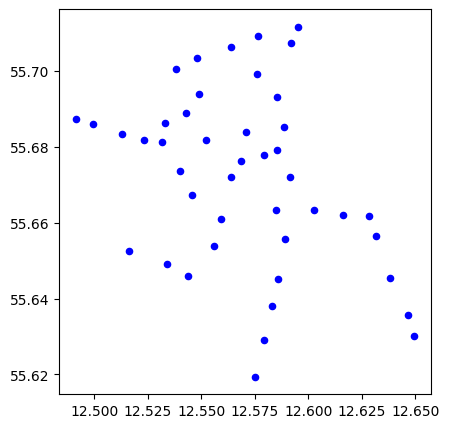

In [77]:
# visualization of metro stops based on geometry point

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 5))

gdf_stops[gdf_stops['location_type'] == 0].plot(ax=ax, 
                                       markersize=20, 
                                       color='blue') 
                                       



In [78]:
# This is a important import for the projection on an actual map
import contextily as cx

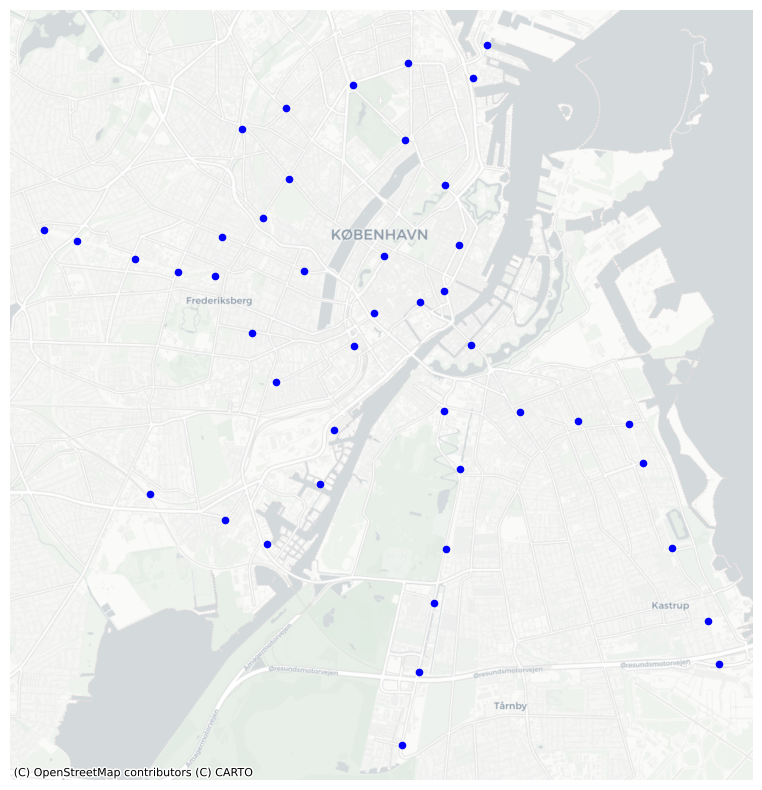

In [81]:
# combine Copenhagen Actual map with stops projection

# Reproject stops to Web Mercator (required by contextily)
gdf_stops_3857 = gdf_stops.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10, 10))

gdf_stops_3857[gdf_stops_3857['location_type'] == 0].plot(ax=ax, 
                                       markersize=20, 
                                       color='blue') 

cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)

ax.set_axis_off()
plt.show()